In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import nflreadpy as nfl

print("All imports successful")

All imports successful


In [28]:
season = 2025
ts = nfl.load_team_stats([season]).to_pandas()

team_stats = (
  ts.query("season == @season")
  .reset_index(drop=True)
)

print(team_stats.to_string())


     season  week team season_type opponent_team  completions  attempts  passing_yards  passing_tds  passing_interceptions  sacks_suffered  sack_yards_lost  sack_fumbles  sack_fumbles_lost  passing_air_yards  passing_yards_after_catch  passing_first_downs  passing_epa  passing_cpoe  passing_2pt_conversions  carries  rushing_yards  rushing_tds  rushing_fumbles  rushing_fumbles_lost  rushing_first_downs  rushing_epa  rushing_2pt_conversions  receptions  targets  receiving_yards  receiving_tds  receiving_fumbles  receiving_fumbles_lost  receiving_air_yards  receiving_yards_after_catch  receiving_first_downs  receiving_epa  receiving_2pt_conversions  special_teams_tds  def_tackles_solo  def_tackles_with_assist  def_tackle_assists  def_tackles_for_loss  def_tackles_for_loss_yards  def_fumbles_forced  def_sacks  def_sack_yards  def_qb_hits  def_interceptions  def_interception_yards  def_pass_defended  def_tds  def_fumbles  def_safeties  misc_yards  fumble_recovery_own  fumble_recovery_yards_

In [29]:
sch = nfl.load_schedules([season]).to_pandas()

sched_raw = (
  sch.query("season == @season")
  .reset_index(drop=True)
)

print(sched_raw.to_string())

             game_id  season game_type  week     gameday   weekday gametime away_team  away_score home_team  home_score location  result  total  overtime old_game_id     gsis nfl_detail_id           pfr    pff       espn   ftn  away_rest  home_rest  away_moneyline  home_moneyline  spread_line  away_spread_odds  home_spread_odds  total_line  under_odds  over_odds  div_game      roof     surface  temp  wind  away_qb_id  home_qb_id      away_qb_name      home_qb_name            away_coach            home_coach         referee stadium_id                          stadium
0    2025_01_DAL_PHI    2025       REG     1  2025-09-04  Thursday    20:20       DAL        20.0       PHI        24.0     Home     4.0   44.0       0.0  2025090400  59843.0          None  202509040phi  28418  401772510  6734          7          7           330.0          -425.0          8.5            -110.0            -110.0        47.5      -110.0     -110.0         1  outdoors       grass  75.0  11.0  00-0033077  00-00

In [30]:
# This creates two rows per game (from schedule df) This will make it so we can merge the two df (team_stats and schedules)
home_view = (
  sched_raw.assign(
    team=sched_raw['home_team'],
    opponent=sched_raw['away_team'],
    is_home=True
  )
)

away_view = (
  sched_raw.assign(
    team=sched_raw['away_team'],
    opponent=sched_raw['home_team'],
    is_home=False
  )
)

team_schedule = (
  pd.concat([home_view, away_view], ignore_index=True)
  .sort_values(['week', 'team'], kind='stable')
  .reset_index(drop=True)
)

# IF true, nothing happens, if false something happens?
assert (team_stats.groupby(['season','week','team']).size().max() == 1), \
       "team_stats has duplicate rows per season-week-team; dedupe/aggregate first"
assert (team_schedule.groupby(['season','week','team']).size().max() == 1), \
       "team_schedule has duplicate rows per season-week-team; inspect schedule"

In [31]:
# Merging the two DataFrames
merged = team_schedule.merge(
    team_stats,
    on=['season','week','team'],
    how='left',
    suffixes=('_sched','_stats')
).sort_values(['team','week'], kind='stable').reset_index(drop=True)

pd.set_option('display.max_rows', None, 'display.max_columns', None, 'display.width', 0)
print(merged.to_string(index=False))

        game_id  season game_type  week    gameday  weekday gametime away_team  away_score home_team  home_score location  result  total  overtime old_game_id    gsis nfl_detail_id          pfr   pff      espn  ftn  away_rest  home_rest  away_moneyline  home_moneyline  spread_line  away_spread_odds  home_spread_odds  total_line  under_odds  over_odds  div_game     roof    surface  temp  wind away_qb_id home_qb_id     away_qb_name     home_qb_name           away_coach           home_coach        referee stadium_id                         stadium team opponent  is_home season_type opponent_team  completions  attempts  passing_yards  passing_tds  passing_interceptions  sacks_suffered  sack_yards_lost  sack_fumbles  sack_fumbles_lost  passing_air_yards  passing_yards_after_catch  passing_first_downs  passing_epa  passing_cpoe  passing_2pt_conversions  carries  rushing_yards  rushing_tds  rushing_fumbles  rushing_fumbles_lost  rushing_first_downs  rushing_epa  rushing_2pt_conversions  recep

In [32]:
# Printing out a list of the columns in the new merged DataFrame
print(merged.columns.tolist())
merged.info()

['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday', 'gametime', 'away_team', 'away_score', 'home_team', 'home_score', 'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest', 'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds', 'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game', 'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id', 'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee', 'stadium_id', 'stadium', 'team', 'opponent', 'is_home', 'season_type', 'opponent_team', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'passing_interceptions', 'sacks_suffered', 'sack_yards_lost', 'sack_fumbles', 'sack_fumbles_lost', 'passing_air_yards', 'passing_yards_after_catch', 'passing_first_downs', 'passing_epa', 'passing_cpoe', 'passing_2pt_conversions', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_fumbles', 'rushing_fumbl

In [33]:
# Useful features and setting x and y axis for classification model

#Creating binary target: 1 = win, 0 = loss
merged['win'] = merged.apply(
  lambda r: 1 if (r['is_home'] and r['result'] > 0) or (not r['is_home'] and r['result'] < 0)
  else 0,
  axis=1
)

feature_cols = [
  # Offensive production
  'passing_yards', 'passing_tds', 'passing_interceptions',
  'rushing_yards', 'rushing_tds', 'rushing_fumbles',
  'receptions', 'receiving_yards', 'receiving_tds',

  # Efficiency & misc
  'sacks_suffered', 'penalties', 'penalty_yards',
  'def_tackles_solo', 'def_interceptions', 'def_tds',
  'def_sacks', 'def_fumbles_forced',

  # Kicking
  'fg_made', 'fg_att', 'pat_made', 'pat_att',

  # Context
  'is_home' # boolean (home vs away)
]

X = merged[feature_cols].fillna(0)
y = merged['win']
print("DataFrames merged.")

DataFrames merged.


Accuracy:  0.8715596330275229
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        88
           1       0.62      0.86      0.72        21

    accuracy                           0.87       109
   macro avg       0.79      0.87      0.82       109
weighted avg       0.90      0.87      0.88       109



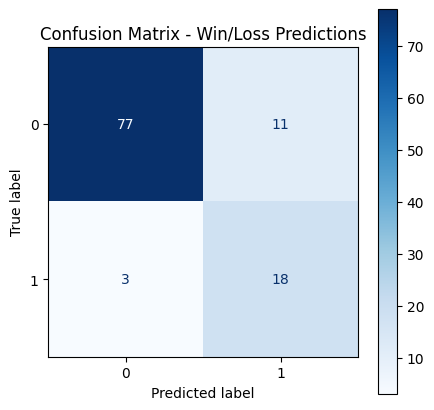

In [34]:
# SPlit, train, evaluate!
# This splits the data
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

# Train a simple model
model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Win/Loss Predictions")
plt.show()

In [35]:
# Add win probabilities
merged['win_prob'] = model.predict_proba(X)[:, 1]

In [36]:
# Auto-detect last completed week & next week
# A game is completed if score exists - comes from schedule
played_mask = merged['home_score'].notna() & merged['away_score'].notna()
last_completed_week = int(merged.loc[played_mask, 'week'].max())
next_week = last_completed_week + 1
print(f"Last completed week: {last_completed_week}  |  Next week: {next_week}")

Last completed week: 7  |  Next week: 8


In [37]:
# Builds latest prior stats per team (to feed {next_week}) - takes a rolling average of the last 3 games played for each team
window = 3

# Latest stats per team strictly BEFORE next_week
rolling_stats = (
    merged.loc[merged['week'] < next_week]
          .sort_values(['team','week'])
          .groupby('team')[feature_cols]
          .rolling(window=window, min_periods=1)
          .mean()
          .reset_index()
)

# Keep only the most recent rolling window per team
latest_rolling = (
    rolling_stats
      .groupby('team', as_index=False)
      .tail(1)
      .reset_index(drop=True)
)

latest_prior = latest_rolling.copy()

# Makes sure feature columns exist
missing = [c for c in feature_cols if c not in latest_prior.columns]
if missing:
  print("WARNING: missing features in latest_prior:", missing)


In [38]:
# Build future team-rows for next week (one row per team in each matchup)

# Next week games at game-level
wk_games = (
  sched_raw.loc[sched_raw['week'] == next_week,
                ['season', 'week', 'game_id', 'home_team', 'away_team']]
              .drop_duplicates()
              .reset_index(drop=True)
)

# Build team-centric rows for the upcoming week
wk_home_rows = (wk_games
      .rename(columns={'home_team': 'team'})
      .assign(opponent=lambda d: d['away_team'],
              is_home=True)
      [['season', 'week', 'game_id', 'team', 'opponent', 'is_home']])

wk_away_rows = (wk_games
      .rename(columns={'away_team': 'team'})
      .assign(opponent=lambda d: d['home_team'],
              is_home=False)
      [['season', 'week', 'game_id', 'team', 'opponent', 'is_home']])

wk_team_rows = pd.concat([wk_home_rows, wk_away_rows], ignore_index=True)


base_features = [c for c in feature_cols if c != 'is_home']
# Attach each teams latest prior stats
wk_team_rows = wk_team_rows.merge(
  latest_prior[['team'] + base_features],
  on='team', how='left'
)

# X for the current model (team-row model)
X_future_team = wk_team_rows[base_features + ['is_home']].fillna(0)
wk_team_rows['team_win_prob'] =  model.predict_proba(X_future_team)[:, 1]
wk_team_rows

,season,week,game_id,team,opponent,is_home,passing_yards,passing_tds,passing_interceptions,rushing_yards,rushing_tds,rushing_fumbles,receptions,receiving_yards,receiving_tds,sacks_suffered,penalties,penalty_yards,def_tackles_solo,def_interceptions,def_tds,def_sacks,def_fumbles_forced,fg_made,fg_att,pat_made,pat_att,team_win_prob
0,2025,8,2025_08_MIN_LAC,LAC,MIN,True,298.000000,2.000000,1.000000,116.333333,0.000000,0.000000,30.333333,298.000000,2.000000,3.000000,7.666667,55.000000,33.000000,1.000000,0.000000,1.333333,0.333333,2.333333,2.333333,2.000000,2.000000,0.773588
1,2025,8,2025_08_MIA_ATL,ATL,MIA,True,268.000000,1.333333,0.333333,133.333333,1.333333,0.333333,20.333333,268.000000,1.333333,1.666667,5.666667,41.000000,33.333333,1.333333,0.000000,2.333333,1.000000,1.333333,1.666667,2.666667,2.666667,0.983520
2,2025,8,2025_08_CHI_BAL,BAL,CHI,True,172.666667,0.333333,1.666667,129.666667,0.666667,0.333333,19.333333,172.666667,0.333333,2.666667,7.333333,61.666667,35.000000,0.000000,0.000000,1.666667,0.333333,1.333333,1.666667,1.000000,1.000000,0.035188
3,2025,8,2025_08_BUF_CAR,CAR,BUF,True,198.333333,2.000000,0.666667,193.333333,0.333333,0.000000,18.333333,198.333333,2.000000,2.000000,6.666667,49.333333,35.333333,0.666667,0.000000,3.000000,0.000000,2.333333,2.333333,2.333333,2.333333,0.920743
4,2025,8,2025_08_NYJ_CIN,CIN,NYJ,True,270.666667,2.666667,1.000000,94.000000,0.000000,0.000000,28.666667,270.666667,2.666667,1.666667,4.333333,27.333333,36.000000,1.000000,0.000000,1.666667,0.333333,2.000000,2.666667,2.333333,2.333333,0.852131
5,2025,8,2025_08_SF_HOU,HOU,SF,True,243.000000,2.333333,0.333333,117.333333,0.666667,0.000000,23.333333,243.000000,2.333333,2.333333,6.666667,60.333333,31.333333,2.000000,0.000000,1.666667,0.666667,2.333333,2.666667,2.666667,2.666667,0.985786
6,2025,8,2025_08_CLE_NE,NE,CLE,True,256.000000,1.666667,0.000000,106.333333,1.000000,0.333333,20.666667,256.000000,1.666667,3.000000,8.000000,64.666667,34.000000,0.666667,0.000000,2.333333,0.666667,1.666667,1.666667,2.666667,2.666667,0.922623
7,2025,8,2025_08_NYG_PHI,PHI,NYG,True,296.333333,2.000000,0.333333,54.333333,0.333333,0.000000,22.000000,296.333333,2.000000,4.000000,7.000000,55.000000,41.333333,0.666667,0.333333,2.000000,0.000000,0.666667,1.000000,2.666667,2.666667,0.706169
8,2025,8,2025_08_TB_NO,NO,TB,True,234.666667,1.000000,1.000000,68.333333,0.333333,0.000000,20.666667,234.666667,1.000000,2.000000,6.666667,46.666667,41.000000,1.000000,0.000000,0.666667,1.000000,2.666667,3.666667,1.666667,1.666667,0.579314
9,2025,8,2025_08_DAL_DEN,DEN,DAL,True,231.666667,1.333333,0.000000,116.666667,1.000000,0.666667,23.333333,231.666667,1.333333,1.666667,10.000000,95.000000,36.333333,0.333333,0.000000,6.333333,0.000000,1.666667,1.666667,1.333333,1.333333,0.784086


In [39]:
# Collapse to one row per game (normalize home/away probs)

# Split home/away predicted rows
home_preds = (wk_team_rows[wk_team_rows['is_home']]
              [['game_id', 'team', 'team_win_prob']]
              .rename(columns={'team_win_prob': 'home_prob'}))
away_preds = (wk_team_rows[~wk_team_rows['is_home']]
              [['game_id', 'team', 'team_win_prob']]
              .rename(columns={'team_win_prob': 'away_prob'}))

matchups_pred = (
  wk_games
    .merge(home_preds, left_on=['game_id', 'home_team'], right_on=['game_id', 'team'])
    .drop(columns=['team'])
    .merge(away_preds, left_on=['game_id', 'away_team'], right_on=['game_id', 'team'])
    .drop(columns=['team'])
)

# Normalize  into one home-win probability per game
eps = 1e-9
matchups_pred['home_win_prob'] = matchups_pred['home_prob'] / (
  matchups_pred['home_prob'] + matchups_pred['away_prob'] + eps
)
matchups_pred['away_win_prob'] = 1.0 - matchups_pred['home_win_prob']

# Sanity checks (optional)
assert (matchups_pred['home_win_prob'].between(0,1)).all()
assert (matchups_pred['away_win_prob'].between(0,1)).all()

# Pretty output
print(matchups_pred[['week','game_id','away_team', 'home_team','away_win_prob','home_win_prob']]
      .sort_values(['week','home_team'])
      .to_string(index=False))

 week         game_id away_team home_team  away_win_prob  home_win_prob
    8 2025_08_MIA_ATL       MIA       ATL       0.135461       0.864539
    8 2025_08_CHI_BAL       CHI       BAL       0.965235       0.034765
    8 2025_08_BUF_CAR       BUF       CAR       0.393748       0.606252
    8 2025_08_NYJ_CIN       NYJ       CIN       0.015434       0.984566
    8 2025_08_DAL_DEN       DAL       DEN       0.559705       0.440295
    8  2025_08_SF_HOU        SF       HOU       0.404400       0.595600
    8 2025_08_TEN_IND       TEN       IND       0.189048       0.810952
    8  2025_08_WAS_KC       WAS        KC       0.460297       0.539703
    8 2025_08_MIN_LAC       MIN       LAC       0.323515       0.676485
    8  2025_08_CLE_NE       CLE        NE       0.489477       0.510523
    8   2025_08_TB_NO        TB        NO       0.622736       0.377264
    8 2025_08_NYG_PHI       NYG       PHI       0.497293       0.502707
    8  2025_08_GB_PIT        GB       PIT       0.500897       0